# Heart Disease Prediction using XGBoost

This notebook covers:
1. Loading and exploring the heart disease data
2. Data preprocessing and scaling
3. Training an XGBoost Classifier
4. Evaluating model performance
5. Saving the model and scaler for deployment

In [1]:
import pandas as pd
import numpy as np
import pickle
import os
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load the Dataset

In [2]:
# Load dataset
try:
    df = pd.read_csv('../data/heart_disease.csv')
except FileNotFoundError:
    # Try relative path from project root if running there
    df = pd.read_csv('data/heart_disease.csv')

# Display basic info
print(f"Total samples: {len(df)}")
print(f"Features: {df.shape[1] - 1}")
print(f"\nTarget distribution:")
print(df['target'].value_counts())

df.head()

Total samples: 20000
Features: 13

Target distribution:
target
1    10000
0    10000
Name: count, dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,0,1,145,244,0,2,139,0,3.4,0,2,2,1
1,37,1,1,122,217,0,1,174,0,1.1,1,0,2,0
2,44,1,2,107,257,0,2,148,0,1.0,2,0,0,0
3,64,0,3,119,215,0,2,166,0,0.0,2,0,0,0
4,54,1,0,139,275,0,0,112,1,3.4,0,1,2,1


## 2. Data Preprocessing

In [3]:
# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# Check for missing values
print("Missing values:")
print(df.isnull().sum())

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [4]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 16000 samples
Test set: 4000 samples


In [5]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed using StandardScaler.")

Feature scaling completed using StandardScaler.


## 3. Train XGBoost Model

In [6]:
# Initialize XGBoost Classifier
model = xgb.XGBClassifier(
    max_depth=5,
    learning_rate=0.1,
    n_estimators=200,
    min_child_weight=3,
    gamma=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

# Train the model
print("Training model...")
model.fit(X_train_scaled, y_train)
print("Model training completed!")

Training model...
Model training completed!


## 4. Evaluate Performance

In [7]:
# Predictions
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)
y_test_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_pred_proba)

print("=" * 30)
print("MODEL PERFORMANCE")
print("=" * 30)
print(f"Training Accuracy:   {train_accuracy:.4f}")
print(f"Test Accuracy:       {test_accuracy:.4f}")
print(f"Test Precision:      {test_precision:.4f}")
print(f"Test Recall:         {test_recall:.4f}")
print(f"Test F1-Score:       {test_f1:.4f}")
print(f"Test ROC-AUC Score:  {test_roc_auc:.4f}")

MODEL PERFORMANCE
Training Accuracy:   0.9880
Test Accuracy:       0.9725
Test Precision:      0.9787
Test Recall:         0.9660
Test F1-Score:       0.9723
Test ROC-AUC Score:  0.9964


In [8]:
# Cross-validation
print("Performing 5-fold cross-validation...")
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"Cross-Validation Scores: {cv_scores}")
print(f"Mean CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

Performing 5-fold cross-validation...
Cross-Validation Scores: [0.97125   0.9721875 0.968125  0.973125  0.97375  ]
Mean CV Score: 0.9717 (+/- 0.0039)


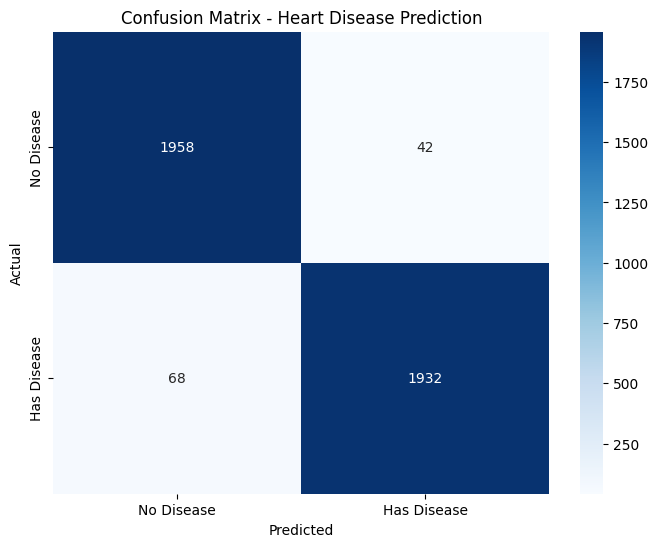

In [9]:
# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Disease', 'Has Disease'],
            yticklabels=['No Disease', 'Has Disease'])
plt.title('Confusion Matrix - Heart Disease Prediction')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

C:\Users\2021ICTS11\AppData\Local\Temp\ipykernel_12360\2919487747.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances, y=feature_importances.index, palette='viridis')


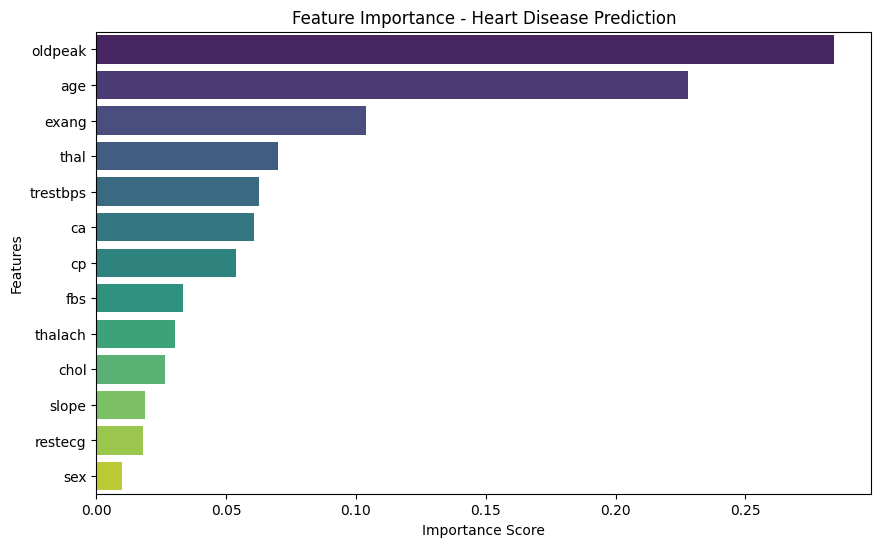

In [10]:
# Feature Importance
plt.figure(figsize=(10, 6))
feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
sns.barplot(x=feature_importances, y=feature_importances.index, palette='viridis')
plt.title('Feature Importance - Heart Disease Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

## 5. Save Model and Scaler

In [11]:
# Create models directory (relative to notebook location)
models_dir = '../models'
os.makedirs(models_dir, exist_ok=True)

# Save the Scaler
scaler_path = os.path.join(models_dir, 'heart_scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"Scaler saved to: {scaler_path}")

# Save the XGBoost model
model_path = os.path.join(models_dir, 'heart_model.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(model, f)
print(f"Model saved to: {model_path}")

Scaler saved to: ../models\heart_scaler.pkl
Model saved to: ../models\heart_model.pkl
